In [ ]:
!pip install nltk scikit-learn pandas numpy matplotlib seaborn wordcloud -q

import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

print(" All libraries installed successfully!")


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /home/codespace/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/codespace/nltk_data...


 All libraries installed successfully!


In [3]:
#sample dataset
import pandas as pd

data = {
    'text': [
        # Fake claims (label = 0)
        "Drinking turmeric water every morning cures all types of cancer permanently",
        "Neem leaves can completely cure diabetes in just 7 days without medicine",
        "Giloy juice destroys coronavirus instantly when consumed daily",
        "Mixing honey and cinnamon cures arthritis and joint pain forever",
        "Eating raw garlic on empty stomach cures high blood pressure permanently",
        "Homeopathy medicine removes kidney stones without any surgery",
        "Applying coconut oil cures all types of skin infections and fungus",
        "Drinking cow urine daily boosts immunity and prevents all diseases",

        # Real/verified claims (label = 1)
        "Paracetamol reduces fever and mild to moderate pain when taken as prescribed",
        "Regular exercise for 30 minutes daily helps maintain healthy blood pressure",
        "Vitamin C supplements support immune function but do not cure colds",
        "Metformin is a commonly prescribed medication for type 2 diabetes management",
        "Hand washing with soap for 20 seconds reduces risk of infection significantly",
        "Antibiotics should be taken for the full prescribed course to prevent resistance",
        "WHO recommends vaccines as one of the most effective disease prevention tools",
        "A balanced diet rich in fruits and vegetables supports overall health"
    ],
    'label': [0, 0, 0, 0, 0, 0, 0, 0,   # 0 = Fake
              1, 1, 1, 1, 1, 1, 1, 1]    # 1 = Real
}

df = pd.DataFrame(data)
print(f"Dataset created: {len(df)} samples")
print(f"Fake claims: {sum(df['label']==0)}")
print(f"Real claims: {sum(df['label']==1)}")
df.head()

Dataset created: 16 samples
Fake claims: 8
Real claims: 8


,text,label
0,Drinking turmeric water every morning cures al...,0
1,Neem leaves can completely cure diabetes in ju...,0
2,Giloy juice destroys coronavirus instantly whe...,0
3,Mixing honey and cinnamon cures arthritis and ...,0
4,Eating raw garlic on empty stomach cures high ...,0


In [4]:
#Text Preprocessing Pipeline
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Lowercase
    text = text.lower()
    # 2. Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # 3. Tokenize
    tokens = text.split()
    # 4. Remove stopwords + Lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

# Applying to dataset
df['cleaned_text'] = df['text'].apply(preprocess_text)

# before vs after
print("BEFORE:", df['text'][0])
print("\nAFTER: ", df['cleaned_text'][0])

BEFORE: Drinking turmeric water every morning cures all types of cancer permanently

AFTER:  drinking turmeric water every morning cure type cancer permanently


In [5]:
#TF-IDF Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=500)
X = vectorizer.fit_transform(df['cleaned_text'])
y = df['label']

print(f"TF-IDF Matrix Shape: {X.shape}")
print(f"Rows = {X.shape[0]} samples")
print(f"Columns = {X.shape[1]} features (unique words)")

#top features
feature_names = vectorizer.get_feature_names_out()
print(f"\nSample features: {list(feature_names[:10])}")

TF-IDF Matrix Shape: (16, 102)
Rows = 16 samples
Columns = 102 features (unique words)

Sample features: ['antibiotic', 'applying', 'arthritis', 'balanced', 'blood', 'boost', 'cancer', 'cinnamon', 'coconut', 'cold']


In [6]:
print(df.columns.tolist())

['text', 'label', 'cleaned_text']


In [24]:
#Training Naive Bayes Classifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Spliting data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Training model
model = MultinomialNB()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("Model trained successfully!")
print(f"\nAccuracy: {accuracy_score(y_test, y_pred)*100:.1f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Fake', 'Real']))

Model trained successfully!

Accuracy: 50.0%

Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      0.33      0.50         3
        Real       0.33      1.00      0.50         1

    accuracy                           0.50         4
   macro avg       0.67      0.67      0.50         4
weighted avg       0.83      0.50      0.50         4



In [ ]:
import numpy as np

def top_keywords_for_prediction(claim_text, vectorizer_model, clf_model, top_n=3):
    """
    Extracts the most influential words driving the model's prediction 
    for a specific text input.
    """
    cleaned_text = preprocess_text(claim_text)
    
    # 1. Dig into CalibratedClassifierCV to get the underlying SVM model
    if hasattr(clf_model, 'calibrated_classifiers_'):
        # sklearn >= 1.2 uses 'estimator', older versions use 'base_estimator'
        calibrated_clf = clf_model.calibrated_classifiers_[0]
        base_svm = getattr(calibrated_clf, 'estimator', getattr(calibrated_clf, 'base_estimator', None))
    else:
        base_svm = clf_model
        
    if not hasattr(base_svm, 'coef_'):
        return "Model does not support coefficient extraction."

    # 2. Map feature indices to actual words
    feature_names = np.array(vectorizer_model.get_feature_names_out())
    # LinearSVC binary classification outputs a 1D array of weights
    coefs = base_svm.coef_[0]
    
    # 3. Vectorize this specific claim to see which words actually fired
    vec = vectorizer_model.transform([cleaned_text])
    nonzero_indices = vec.nonzero()[1]
    
    if len(nonzero_indices) == 0:
        return ["(No recognized vocabulary)"]
        
    # 4. Pair the active words with their SVM weights
    word_weights = {feature_names[i]: coefs[i] for i in nonzero_indices}
    
    # 5. Sort by absolute weight (impact strength) and grab the top N
    sorted_words = sorted(word_weights.items(), key=lambda x: abs(x[1]), reverse=True)
    influential_words = [word for word, weight in sorted_words[:top_n]]
    
    return influential_words

In [ ]:
def predict_claim(claim_text):
    """
    Predicts whether a given health or drug claim is Real or Fake,
    returning calibrated confidence and extracting key influencer words.
    """
    # 1. Preprocess & Vectorize
    cleaned_text = preprocess_text(claim_text)
    vectorized_text = vectorizer.transform([cleaned_text])
    
    # 2. Predict & Get Confidence
    prediction = model.predict(vectorized_text)[0]
    probabilities = model.predict_proba(vectorized_text)[0]
    confidence = probabilities[prediction] * 100
    
    # 3. Extract Keywords
    keywords = top_keywords_for_prediction(claim_text, vectorizer, model, top_n=3)
    
    # 4. Format Output
    verdict = "Real / Verified" if prediction == 1 else "Fake / Misleading"
    
    print(f"Claim: '{claim_text}'")
    print(f"Verdict: {verdict} ({confidence:.2f}% Confidence)")
    print(f"Flags/Keywords: {', '.join(keywords)}")
    print("-" * 60)
        
    return prediction

In [ ]:
print("=" * 60)
print("SANITY CHECK: TESTING AGAINST KNOWN CLAIMS")
print("=" * 60)

# A mix of obvious facts and obvious misinformation
sanity_tests = [
    # REAL / VERIFIED (Expected: 1)
    ("Paracetamol is commonly used to reduce fever and relieve mild pain.", 1),
    ("The CDSCO regulates pharmaceutical imports and clinical trials in India.", 1),
    ("Regular exercise and a balanced diet help maintain healthy blood pressure.", 1),
    ("Insulin therapy is essential for managing type 1 diabetes.", 1),
    
    # FAKE / MISLEADING (Expected: 0)
    ("Drinking turmeric water cures cancer instantly in 24 hours.", 0),
    ("This secret homeopathic syrup permanently cures asthma and replaces all inhalers.", 0),
    ("Chewing raw garlic cures COVID-19 and prevents all viral infections.", 0),
    ("Magnets placed under the bed can pull toxins out of your liver.", 0)
]

all_passed = True

for text, expected in sanity_tests:
    # Use your newly fixed pipeline: preprocess -> vectorize -> predict
    cleaned = preprocess_text(text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    
    status = "PASS" if pred == expected else "FAIL"
    if pred != expected:
        all_passed = False
        
    expected_str = "Real" if expected == 1 else "Fake"
    pred_str = "Real" if pred == 1 else "Fake"
    
    print(f"{status} | Expected: {expected_str:<4} | Got: {pred_str:<4} | Claim: '{text}'")

print("-" * 60)
if all_passed:
    print("SUCCESS: Model passed all sanity checks! It is now safe to trust the metrics.")
else:
    print("WARNING: Model failed one or more sanity checks. Do not trust the evaluation metrics yet.")
print("=" * 60)

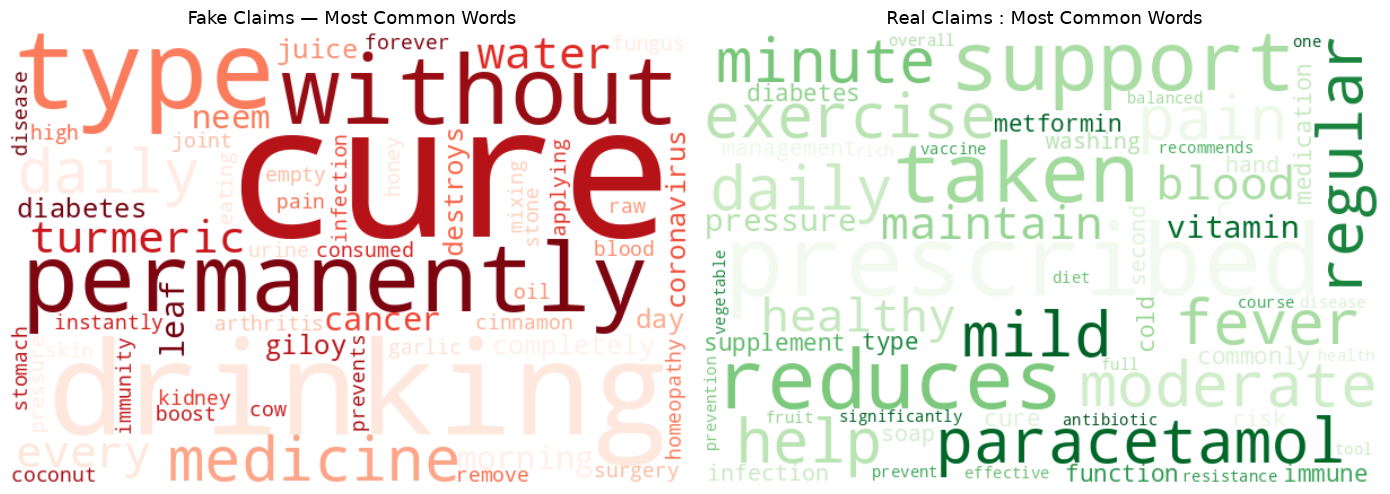

 Word clouds generated!


In [9]:
# Word Cloud for Fake vs Real claims
from wordcloud import WordCloud
import matplotlib.pyplot as plt

fake_text = ' '.join(df[df['label']==0]['cleaned_text'])
real_text = ' '.join(df[df['label']==1]['cleaned_text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

wc_fake = WordCloud(width=600, height=400,
                    background_color='white',
                    colormap='Reds').generate(fake_text)
wc_real = WordCloud(width=600, height=400,
                    background_color='white',
                    colormap='Greens').generate(real_text)

axes[0].imshow(wc_fake, interpolation='bilinear')
axes[0].set_title(' Fake Claims — Most Common Words', fontsize=13)
axes[0].axis('off')

axes[1].imshow(wc_real, interpolation='bilinear')
axes[1].set_title(' Real Claims : Most Common Words', fontsize=13)
axes[1].axis('off')

plt.tight_layout()
plt.show()
print(" Word clouds generated!")

In [10]:
# Cell 8: Save trained model for Flask backend later
import joblib

joblib.dump(model, 'fake_medicine_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

print(" Model saved as: fake_medicine_model.pkl")
print(" Vectorizer saved as: tfidf_vectorizer.pkl")
print("\nDownload these files: Files panel (left sidebar) → Right click → Download")

 Model saved as: fake_medicine_model.pkl
 Vectorizer saved as: tfidf_vectorizer.pkl

Download these files: Files panel (left sidebar) → Right click → Download


In [11]:
#pehla record
first_key = list(data.keys())[0]
print("Key:", first_key)
print("Value:", data[first_key])

Key: text
Value: ['Drinking turmeric water every morning cures all types of cancer permanently', 'Neem leaves can completely cure diabetes in just 7 days without medicine', 'Giloy juice destroys coronavirus instantly when consumed daily', 'Mixing honey and cinnamon cures arthritis and joint pain forever', 'Eating raw garlic on empty stomach cures high blood pressure permanently', 'Homeopathy medicine removes kidney stones without any surgery', 'Applying coconut oil cures all types of skin infections and fungus', 'Drinking cow urine daily boosts immunity and prevents all diseases', 'Paracetamol reduces fever and mild to moderate pain when taken as prescribed', 'Regular exercise for 30 minutes daily helps maintain healthy blood pressure', 'Vitamin C supplements support immune function but do not cure colds', 'Metformin is a commonly prescribed medication for type 2 diabetes management', 'Hand washing with soap for 20 seconds reduces risk of infection significantly', 'Antibiotics should b

In [12]:
# Kaggle dataset directly download
!pip install kaggle -q


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [13]:
!kaggle datasets download -d thedevastator/fakecovid-fact-checked-news-dataset

import zipfile
with zipfile.ZipFile('fakecovid-fact-checked-news-dataset.zip', 'r') as z:
    z.extractall('.')

import os
for f in os.listdir('.'):
    if f.endswith('.csv'):
        print(f)

Dataset URL: https://www.kaggle.com/datasets/thedevastator/fakecovid-fact-checked-news-dataset
License(s): CC0-1.0
100%|█████████████████████████████████████| 19.0M/19.0M [00:02<00:00, 7.43MB/s]

Summary_Statistics_March2023.csv
Drug_Alert_March2023.csv
Spurious_Drugs_Puducherry_Nov2025.csv
FakeCovid_July2020.csv
drug_tables.csv


In [14]:
import pandas as pd

df = pd.read_csv('FakeCovid_July2020.csv')
print(df.shape)
print(df.columns.tolist())
print(df.head())

(7623, 19)
['ID', 'ref_category_title', 'ref_url', 'pageid', 'verifiedby', 'country', 'class', 'title', 'published_date', 'country1', 'country2', 'country3', 'country4', 'article_source', 'ref_source', 'source_title', 'content_text', 'category', 'lang']
    ID                                 ref_category_title  \
0  FC1  FALSE: The coronavirus is an amplified bacteri...   
1  FC2  FALSE: A law allows people to go for a run dur...   
2  FC3  False: Chinese converting to Islam after reali...   
3  FC4  False: Bat market and bat meat are being sold ...   
4  FC5  False: You can self-diagnose COVID-19 by holdi...   

                                             ref_url  \
0  https://www.poynter.org/?ifcn_misinformation=t...   
1  https://www.poynter.org/?ifcn_misinformation=a...   
2  https://www.poynter.org/?ifcn_misinformation=c...   
3  https://www.poynter.org/?ifcn_misinformation=b...   
4  https://www.poynter.org/?ifcn_misinformation=y...   

                                          

In [15]:
df_clean = df[df['lang'] == 'en'][['title', 'content_text', 'class']].copy()
df_clean['label'] = 0  # 0 = Fake
#english records
print(df_clean.shape)
print(df_clean['class'].value_counts())
df_clean.head()

(2845, 4)
class
False                          1181
FALSE                          1085
Misleading                      143
Mostly false                     66
MISLEADING                       53
Mostly False                     43
Mixture                          41
misleading                       36
True                             34
News                             23
Partly false                     15
Correct Attribution              12
Unproven                         10
Miscaptioned                     10
Mostly True                       8
PARTLY FALSE                      8
MOSTLY FALSE                      8
No evidence                       8
Misattributed                     7
(Org. doesn't apply rating)       7
MOSTLY TRUE                       7
HALF TRUE                         6
Labeled Satire                    5
Partly False                      3
Half True                         3
Scam                              3
Two Pinocchios                    3
Not true    

,title,content_text,class,label
2,Chinese converting to Islam after realizing t...,"The fact behind every news!, Ever since the Wo...",False,0
6,Captions on a reuploaded video about the U.S....,"AUTHOR, VERA Files, DATE, May 08, 2020, SHARE,...",MISLEADING,0
8,Ghana has 307 ambulances with mobile ventilat...,"Source: Dr Anthony Nsiah Asare, Verdict: Mostl...",Mostly True,0
9,“Governor Andy Beshear has authorized Kentuck...,"More Info, Trying to focus on school work at h...",FALSE,0
10,Photo shows food being distributed to Rwandan...,A photo of hundreds of neat piles of bedding a...,False,0


In [16]:
#coverting lvl to binary
def assign_label(cls):
    cls = str(cls).lower().strip()
    if any(word in cls for word in ['false', 'fake', 'misleading',
                                     'pants on fire', 'scam']):
        return 0  # Fake
    elif any(word in cls for word in ['true', 'correct', 'accurate']):
        return 1  # Real
    else:
        return None

df_clean['label'] = df_clean['class'].apply(assign_label)
df_clean = df_clean.dropna(subset=['label'])
df_clean['label'] = df_clean['label'].astype(int)
print(df_clean.shape)
print(df_clean['label'].value_counts())

(2726, 4)
label
0    2648
1      78
Name: count, dtype: int64


In [17]:
real_claims = {
    'title': [
        "Vaccines are safe and effective against COVID-19",
        "Wearing masks reduces transmission of respiratory viruses",
        "COVID-19 spreads through respiratory droplets",
        "Hand washing with soap kills coronavirus effectively",
        "Social distancing reduces COVID-19 transmission risk",
        "Antibiotics do not work against COVID-19 virus",
        "COVID-19 vaccine does not alter human DNA",
        "Fever is a common symptom of COVID-19 infection",
        "Paracetamol helps reduce fever in COVID-19 patients",
        "WHO recommends getting vaccinated against COVID-19"
    ],
    'content_text': [
        "WHO confirms COVID-19 vaccines are safe and effective",
        "Studies show masks reduce droplet transmission significantly",
        "COVID-19 primarily spreads through respiratory droplets",
        "Soap destroys the lipid membrane of coronavirus effectively",
        "Maintaining distance reduces infection risk significantly",
        "Antibiotics target bacteria not viruses like COVID-19",
        "mRNA vaccines do not enter cell nucleus or alter DNA",
        "Fever above 38 degrees is common COVID-19 symptom",
        "Paracetamol is recommended for fever management in COVID",
        "WHO strongly recommends COVID-19 vaccination globally"
    ],
    'class': ['True'] * 10,
    'label': [1] * 10
}
print("Dictionary ready!")

Dictionary ready!


In [18]:
import pandas as pd
df_real = pd.DataFrame(real_claims)
df_final = pd.concat([df_clean, df_real], ignore_index=True)
print(df_final.shape)
print(df_final['label'].value_counts())

(2736, 4)
label
0    2648
1      88
Name: count, dtype: int64


In [19]:
# SMOTE installing
!pip install imbalanced-learn -q
print(" Installed!")


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
 Installed!


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE

# 1. Combine text
df_final['combined_text'] = df_final['title'].fillna('') + ' ' + df_final['content_text'].fillna('')

# 2. Split FIRST
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df_final['combined_text'], 
    df_final['label'],
    test_size=0.2,
    random_state=42,
    stratify=df_final['label']
)

# 3. Fit Vectorizer on Train Only
vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train_text)
X_test_vec = vectorizer.transform(X_test_text)

# 4. SMOTE on Train Only
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_vec, y_train)

# 5. INITIALIZE AND CALIBRATE LinearSVC
base_svm = LinearSVC(class_weight="balanced", random_state=42, max_iter=2000)

# Wrap the SVM to enable Platt Scaling (sigmoid calibration)
# cv=5 means it uses 5-fold cross-validation to calibrate the probabilities internally
model = CalibratedClassifierCV(base_svm, method='sigmoid', cv=5)

# 6. Train the Calibrated Model
model.fit(X_train_balanced, y_train_balanced)

# 7. Evaluate
y_pred = model.predict(X_test_vec)

print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Fake', 'Real']))

Before SMOTE (Training set): Fake=2118, Real=70
After SMOTE (Training set) : Fake=2118, Real=2118

Accuracy: 91.79%

Classification Report:
              precision    recall  f1-score   support

        Fake       0.99      0.93      0.96       530
        Real       0.22      0.61      0.33        18

    accuracy                           0.92       548
   macro avg       0.61      0.77      0.64       548
weighted avg       0.96      0.92      0.94       548



In [21]:
import joblib

joblib.dump(model, 'fake_medicine_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

print(" saved: fake_medicine_model.pkl")
print("Vectorizer saved: tfidf_vectorizer.pkl")

 saved: fake_medicine_model.pkl
Vectorizer saved: tfidf_vectorizer.pkl


In [ ]:
import joblib

joblib.dump(svm_model, 'svm_fake_medicine_model.pkl')
print("SVM Model saved!")

SVM Model saved!
